## Использование моделей

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [16]:
# Загрузка данных
dataset = pd.read_csv('data/obesity_test_full.csv', sep=",")
X = dataset.drop('BMI', axis=1)  # Все признаки, кроме BMI
X = X.drop('Obesity', axis=1)  # Все признаки, кроме целевой переменной
y = dataset['Obesity']  # Целевая переменная

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Бэггинг (Random Forest и Extra Trees)

In [17]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Случайный лес (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Сверхслучайные деревья (Extra Trees)
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, y_train)

ExtraTreesClassifier(random_state=42)

### AdaBoost

In [18]:
from sklearn.ensemble import AdaBoostClassifier

# AdaBoost с Decision Tree в качестве базового классификатора
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

### Градиентный бустинг (Gradient Boosting)

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

# Градиентный бустинг
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

# Оценка качества моделей

Метрики для оценки:
- Accuracy (точность) — доля правильных предсказаний.
- F1-score — среднее гармоническое precision и recall (важно при дисбалансе классов).
- ROC-AUC — площадь под ROC-кривой (оценивает качество вероятностных предсказаний).

In [20]:
models = {
    "Random Forest": rf,
    "Extra Trees": et,
    "AdaBoost": ada,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Вероятность класса 1
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

# Результаты в виде DataFrame
results_df = pd.DataFrame(results)
print(results_df)

               Model  Accuracy  F1-score   ROC-AUC
0      Random Forest  0.985646  0.990354  0.998770
1        Extra Trees  0.974482  0.982721  0.996873
2           AdaBoost  0.984051  0.989247  0.999193
3  Gradient Boosting  0.992026  0.994629  0.999326


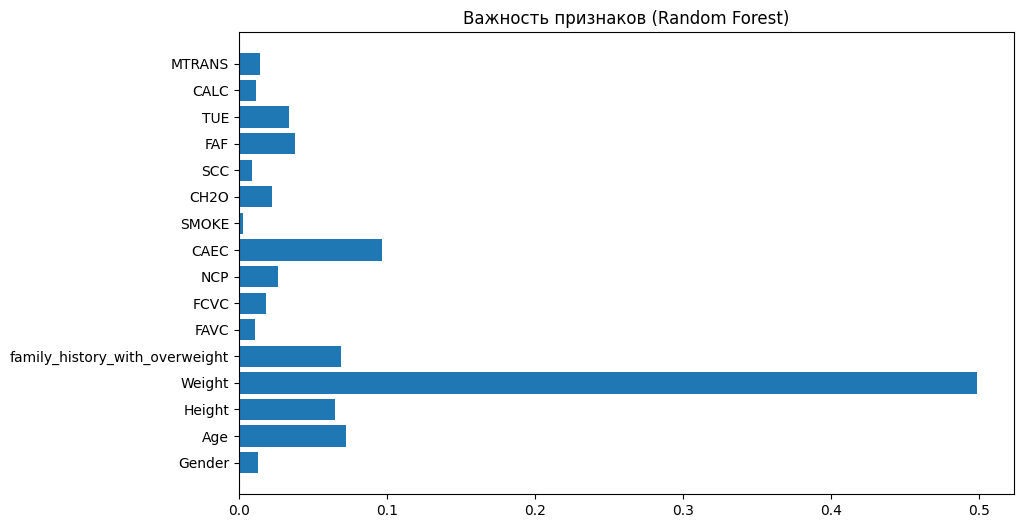

In [21]:
import matplotlib.pyplot as plt

# Важность признаков для Random Forest
plt.figure(figsize=(10, 6))
plt.barh(X.columns, rf.feature_importances_)
plt.title("Важность признаков (Random Forest)")
plt.show()